In [2]:
import pandas as pd

file_path = r'./data/train.parquet'

df = pd.read_parquet(file_path)

print(df.head(20)) 
print(df.info())
print(df.shape)

   row_id  time_id  investment_id    target       f_0       f_1       f_2  \
0     0_1        0              1 -0.300875  0.932573  0.113691 -0.402206   
1     0_2        0              2 -0.231040  0.810802 -0.514115  0.742368   
2     0_6        0              6  0.568807  0.393974  0.615937  0.567806   
3     0_7        0              7 -1.064780 -2.343535 -0.011870  1.874606   
4     0_8        0              8 -0.531940  0.842057 -0.262993  2.330030   
5     0_9        0              9  1.505904  0.608855  1.369305 -0.761515   
6    0_10        0             10 -0.260731 -1.863797  0.113691  1.573864   
7    0_12        0             12 -0.469207  0.408954 -0.765238  0.261430   
8    0_13        0             13  0.094525  0.861187  2.373796 -1.148977   
9    0_14        0             14 -0.251120 -2.476555  0.239253  2.222353   
10   0_16        0             16 -0.130481  0.686414 -0.514115 -1.465751   
11   0_17        0             17  0.365578  0.081737  1.745989 -1.218067   

In [4]:
print(df.columns)

Index(['row_id', 'time_id', 'investment_id', 'target', 'f_0', 'f_1', 'f_2',
       'f_3', 'f_4', 'f_5',
       ...
       'f_290', 'f_291', 'f_292', 'f_293', 'f_294', 'f_295', 'f_296', 'f_297',
       'f_298', 'f_299'],
      dtype='object', length=304)


In [6]:
length = df.shape[0]
time_steps = df.time_id.nunique()
assets = df.investment_id.nunique()
print(f"len: {length} \t number of assets: {assets} \t time steps: {time_steps}")

len: 3141410 	 number of assets: 3579 	 time steps: 1211


In [10]:
print(f"number of assets: {assets} (range from {df.investment_id.min()} to {df.investment_id.max()})")

number of assets: 3579 (range from 0 to 3773)


investment_id
0      461
1     1108
2     1003
3     1076
4      316
6     1082
7      625
8     1087
9      936
10    1161
Name: target, dtype: int64


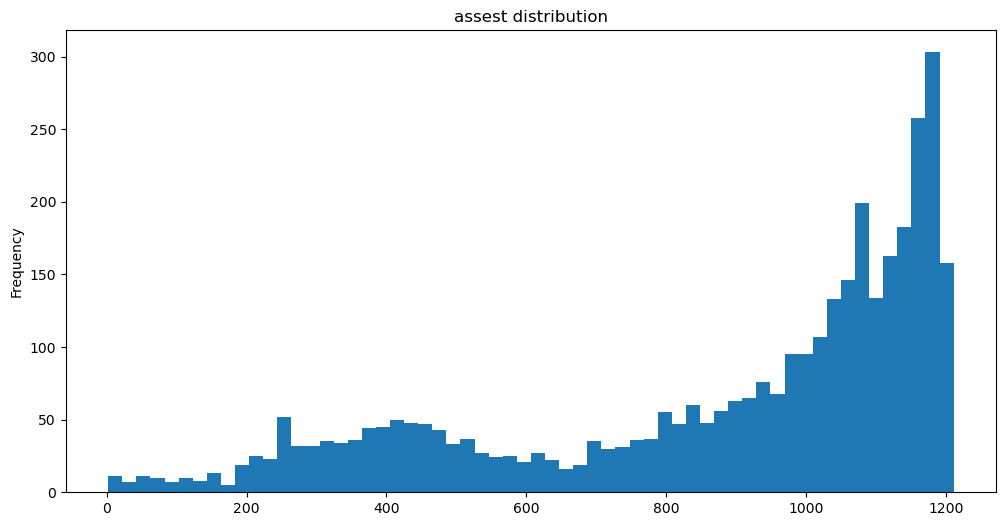

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
obs_by_asset = df.groupby(['investment_id'])['target'].count()
print(obs_by_asset.head(10))
fix, ax = plt.subplots(1, 1, figsize=(12, 6))
obs_by_asset.plot.hist(bins=60)
plt.title('assest distribution')
plt.show()

time_id
0    2272
1    2275
2    2275
3    2285
4    2273
5    2280
6    2280
7    2271
8    2254
9    2269
Name: target, dtype: int64


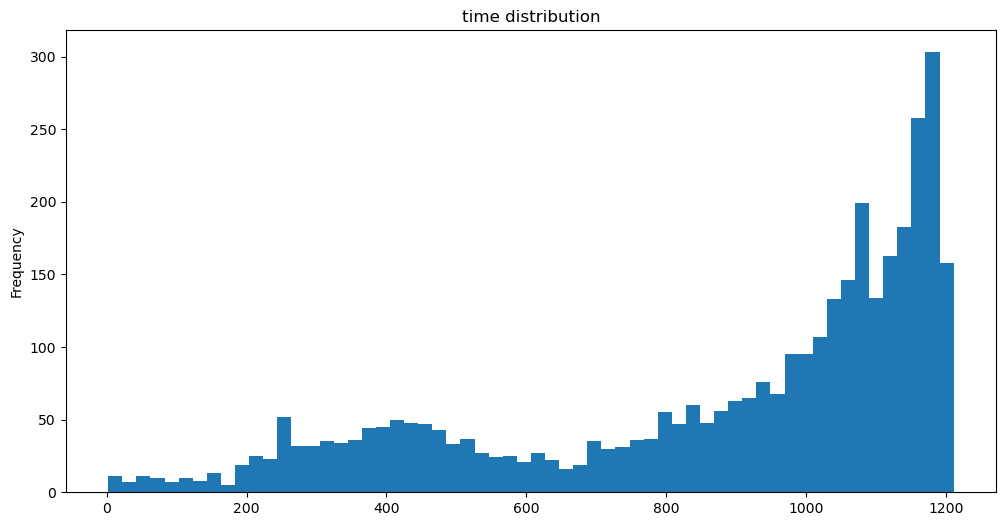

In [20]:
obs_by_time = df.groupby(['time_id'])['target'].count()
print(obs_by_time.head(10))
fix, ax = plt.subplots(1, 1, figsize=(12, 6))
obs_by_asset.plot.hist(bins=60)
plt.title('time distribution')
plt.show()

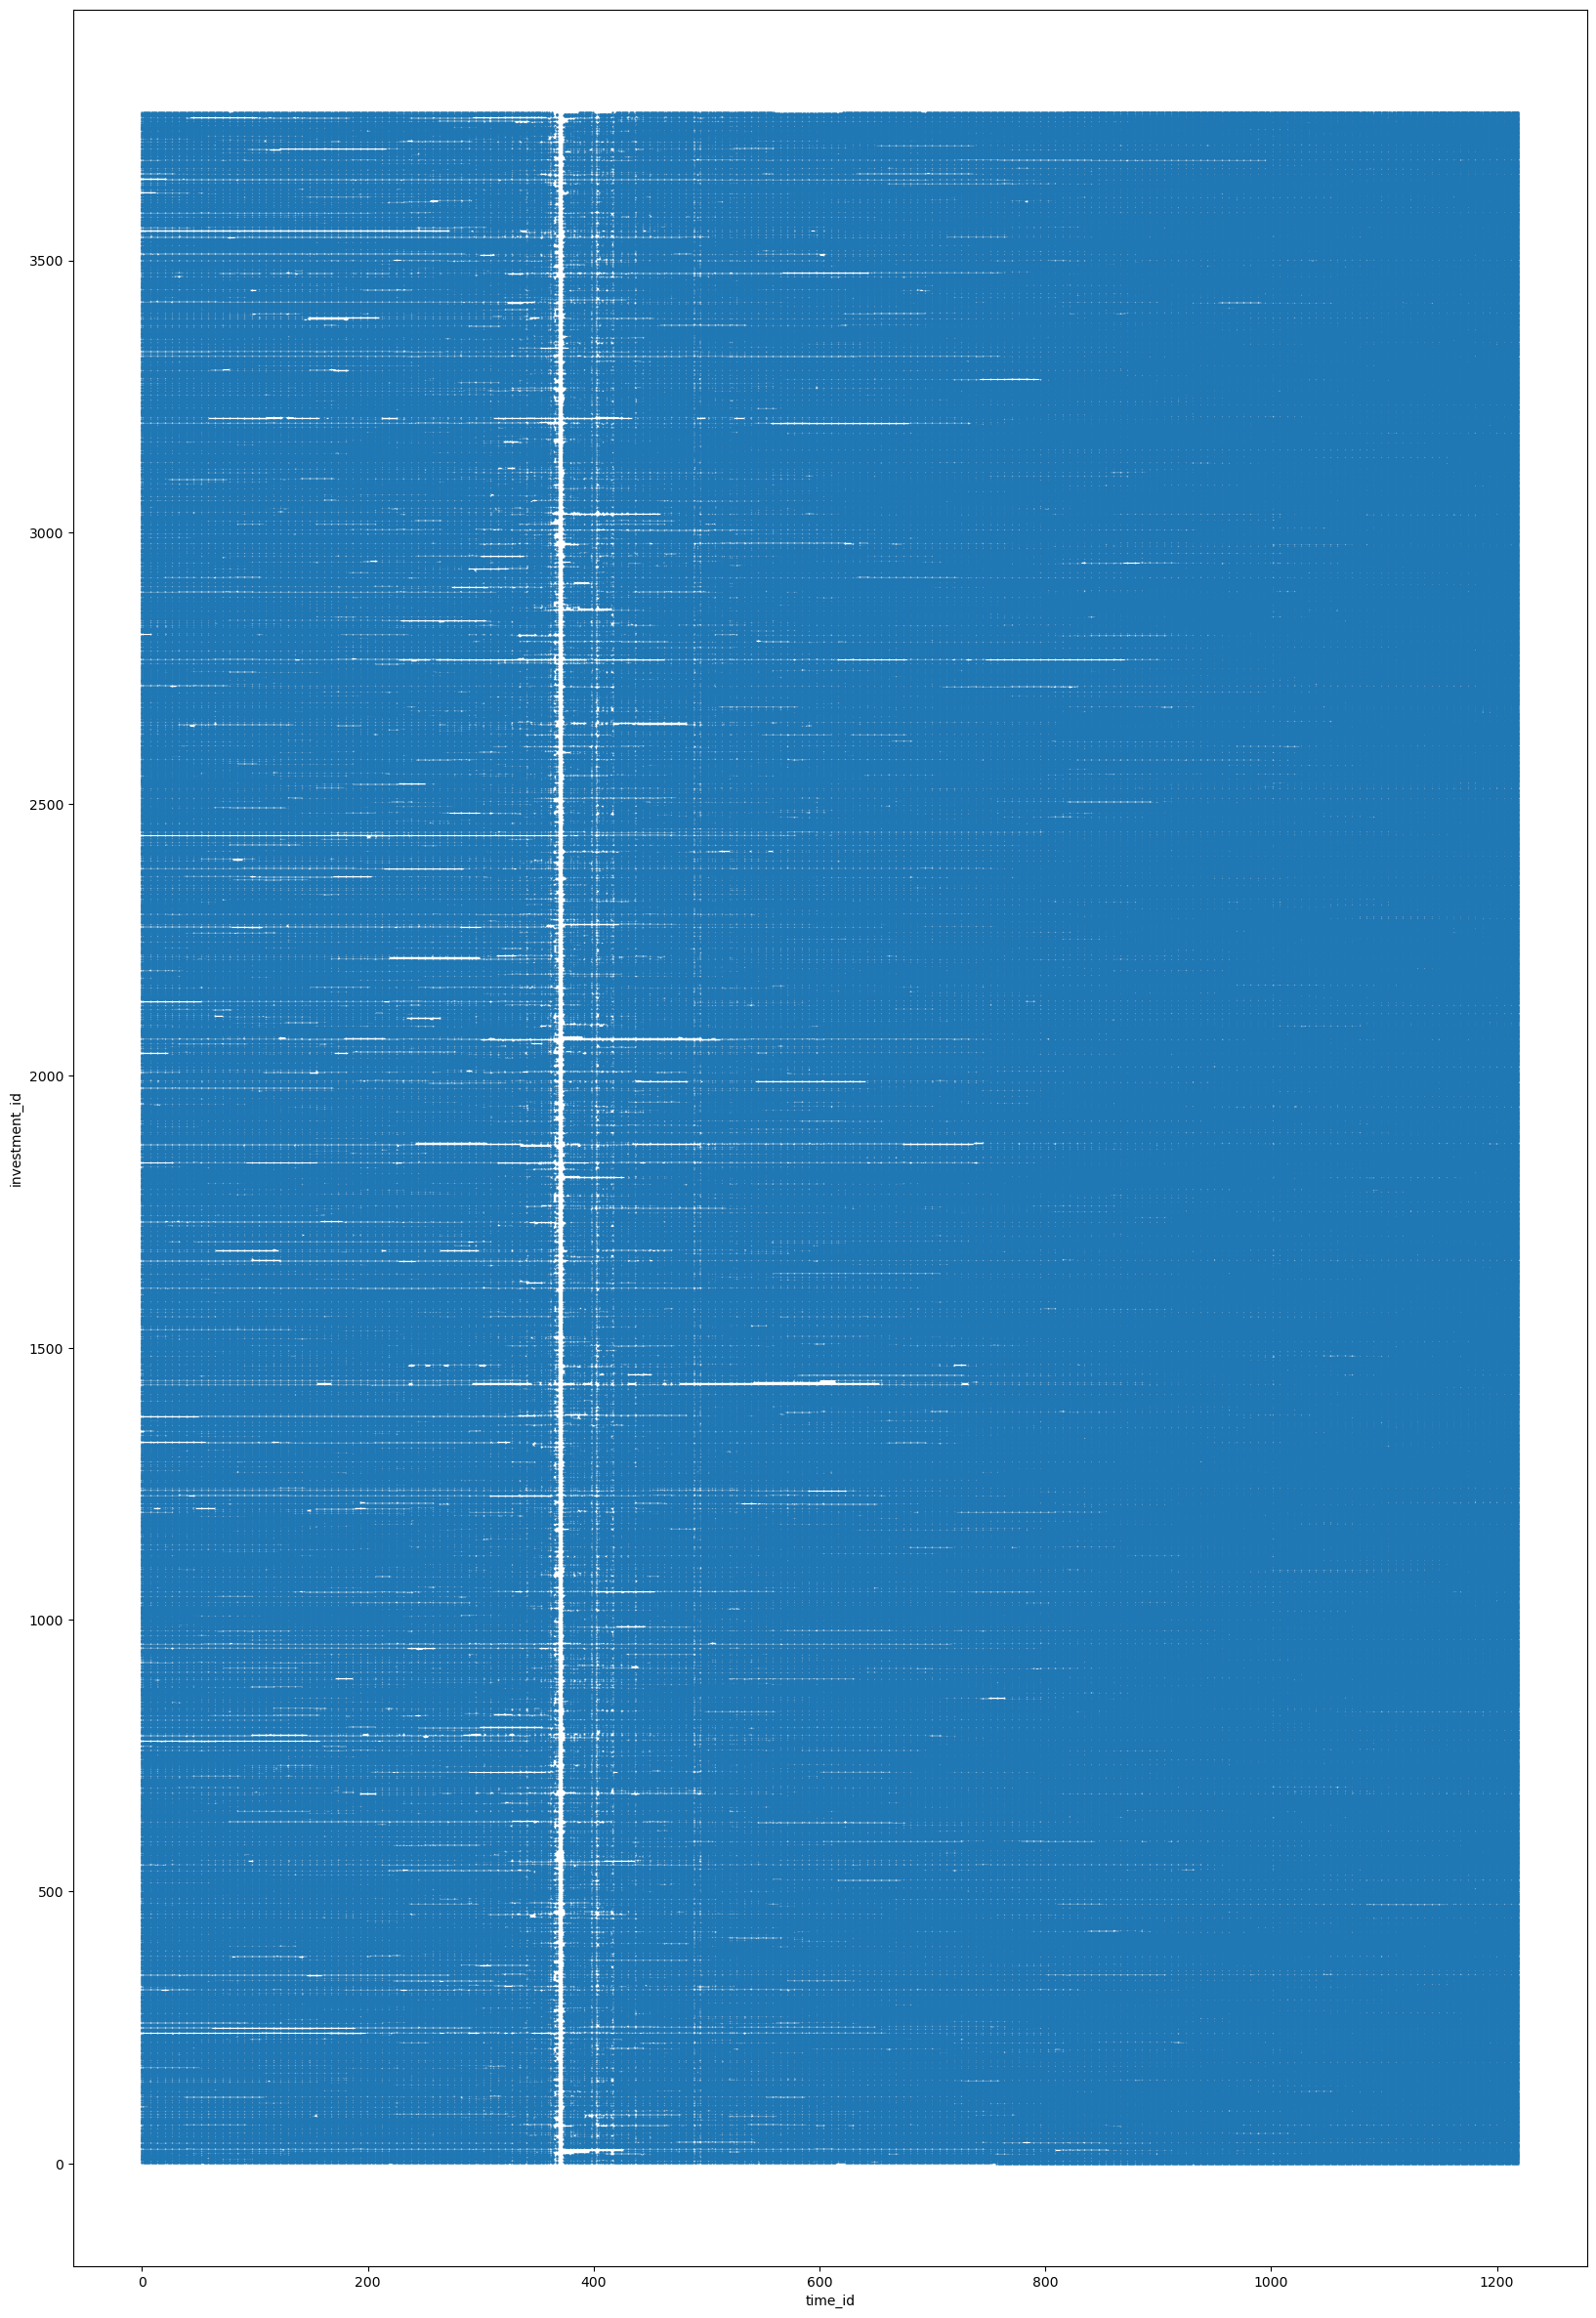

In [22]:
df[['investment_id', 'time_id']].plot.scatter('time_id', 'investment_id', figsize=(20, 30), s=0.5)
plt.show()

investment_id
0     0.052841
1    -0.025687
2    -0.051106
3     0.046773
4    -0.047773
6     0.023042
7    -0.085509
8     0.036489
9     0.041099
10   -0.040795
Name: target, dtype: float64


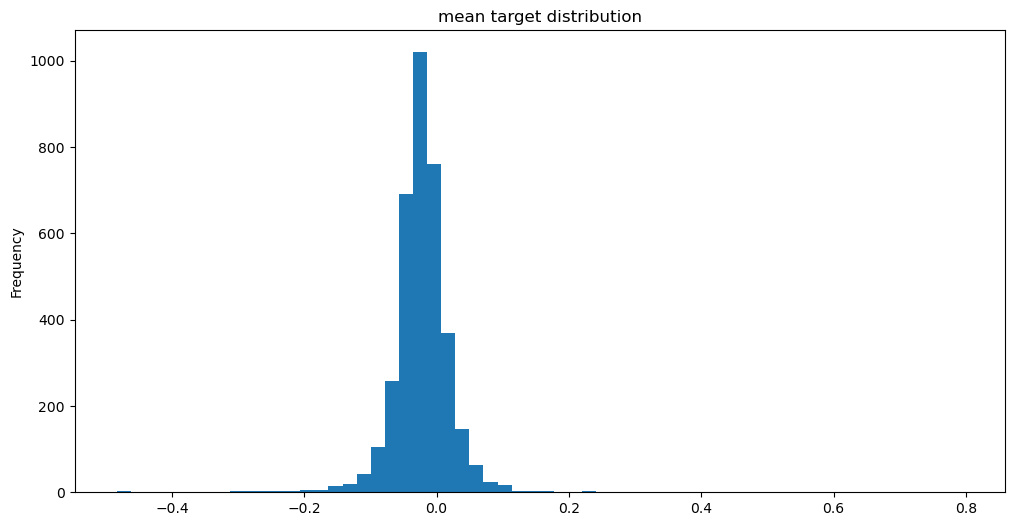

Mean of mean target: -0.02310


In [24]:
mean_target = df.groupby(['investment_id'])['target'].mean()
mean_mean_target = np.mean(mean_target)
print(mean_target.head(10))
fig, ax = plt.subplots(1, 1, figsize=(12, 6))
mean_target.plot.hist(bins=60)
plt.title("mean target distribution")
plt.show()

print(f"Mean of mean target: {mean_mean_target: 0.5f}")

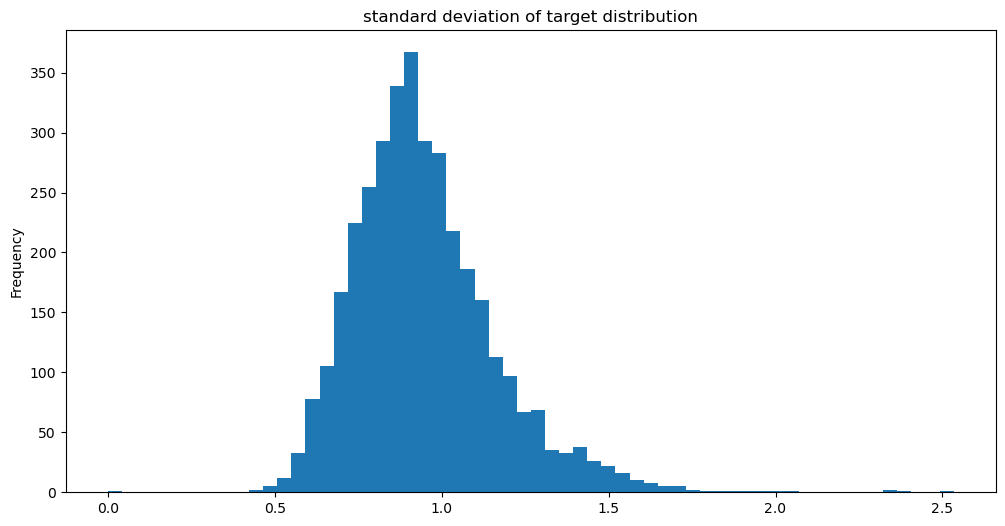

Mean of std target:  0.94790


In [26]:
sts_target = df.groupby(['investment_id'])['target'].std()
mean_std_target = np.mean(sts_target)

fig, ax = plt.subplots(1, 1, figsize=(12, 6))
sts_target.plot.hist(bins=60)
plt.title("standard deviation of target distribution")
plt.show()

print(f"Mean of std target: {mean_std_target: 0.5f}")

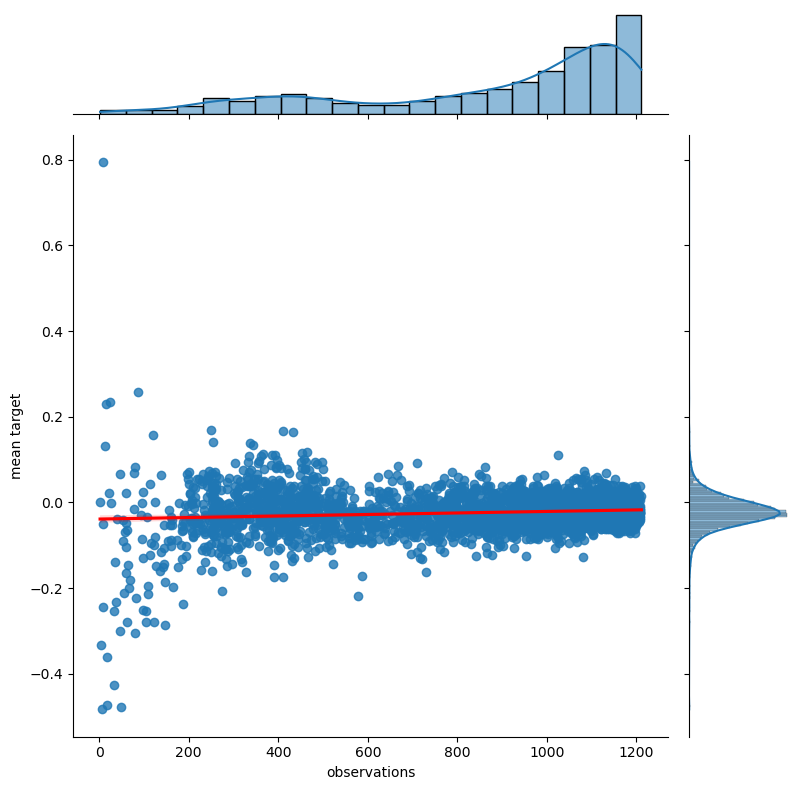

In [28]:
ax = sns.jointplot(x=obs_by_asset, y=mean_target, kind="reg", 
                   height=8, joint_kws={'line_kws':{'color':'red'}})
ax.ax_joint.set_xlabel('observations')
ax.ax_joint.set_ylabel('mean target')
plt.show()

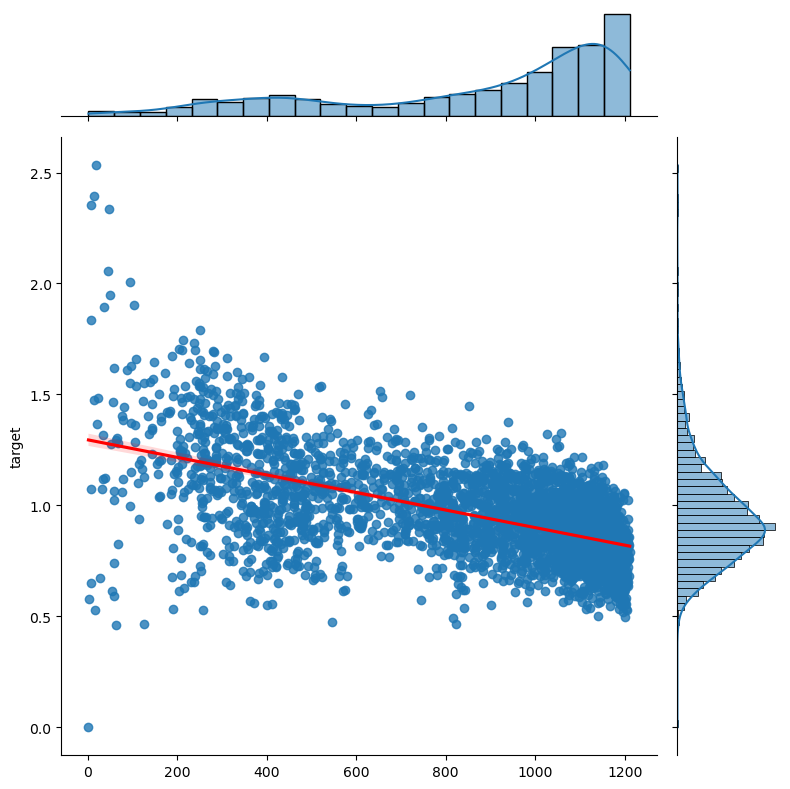

In [30]:
qx = sns.jointplot(x=obs_by_asset.values, y=sts_target, kind="reg", 
                   height=8, joint_kws={'line_kws':{'color':'red'}})
ax.ax_joint.set_xlabel('observations')
ax.ax_joint.set_ylabel('std target')
plt.show()

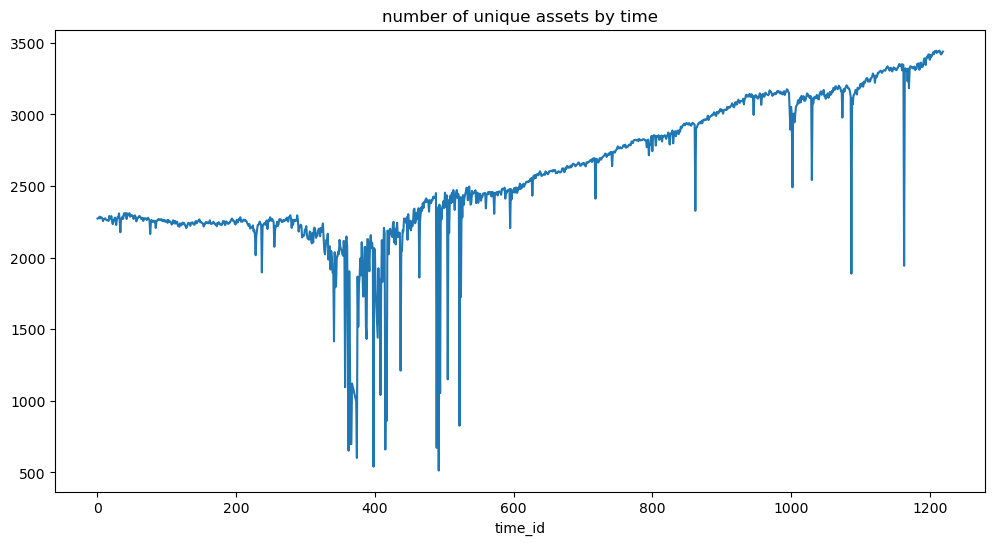

In [34]:
fig, ax = plt.subplots(1, 1, figsize=(12, 6))
df.groupby('time_id')['investment_id'].nunique().plot()
plt.title("number of unique assets by time")
plt.show()

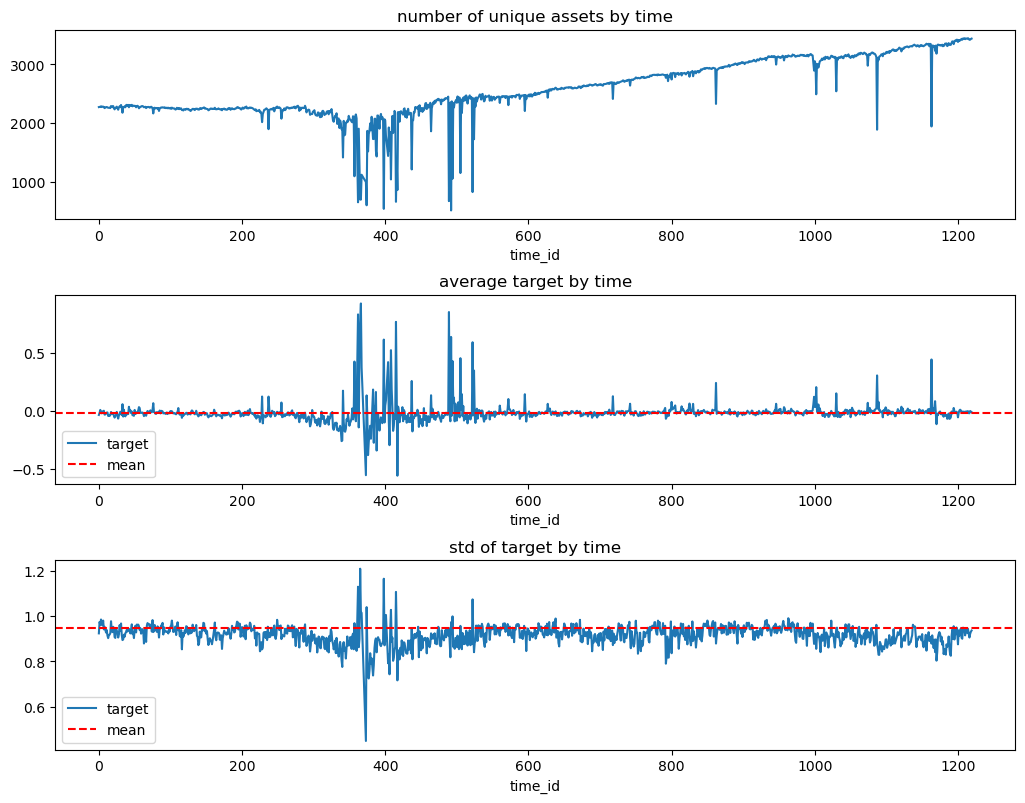

In [40]:
plt.figure(figsize=(12, 6))

plt.subplot(3, 1, 1,)
(df.groupby('time_id')['investment_id'].nunique()).plot()
plt.title("number of unique assets by time")

plt.subplot(3, 1, 2)
df.groupby('time_id')['target'].mean().plot()
plt.title("average target by time")
plt.axhline(y=mean_mean_target, color='r', linestyle='--', label="mean")
plt.legend(loc='lower left')

plt.subplot(3, 1, 3)
df.groupby('time_id')['target'].std().plot()
plt.title("std of target by time")
plt.axhline(y=mean_std_target, color='r', linestyle='--', label="mean")
plt.legend(loc='lower left')

plt.subplots_adjust(left=0.1,
                    bottom=0.1, 
                    right=0.9, 
                    top=1.3, 
                    wspace=0.4, 
                    hspace=0.4)

plt.show()

In [46]:
r = np.corrcoef(df.groupby('time_id')['investment_id'].nunique(), df.groupby('time_id')['target'].mean())[0][1]
print(f"Correlation of number of assets by target: {r:0.3f}")

Correlation of number of assets by target: -0.184


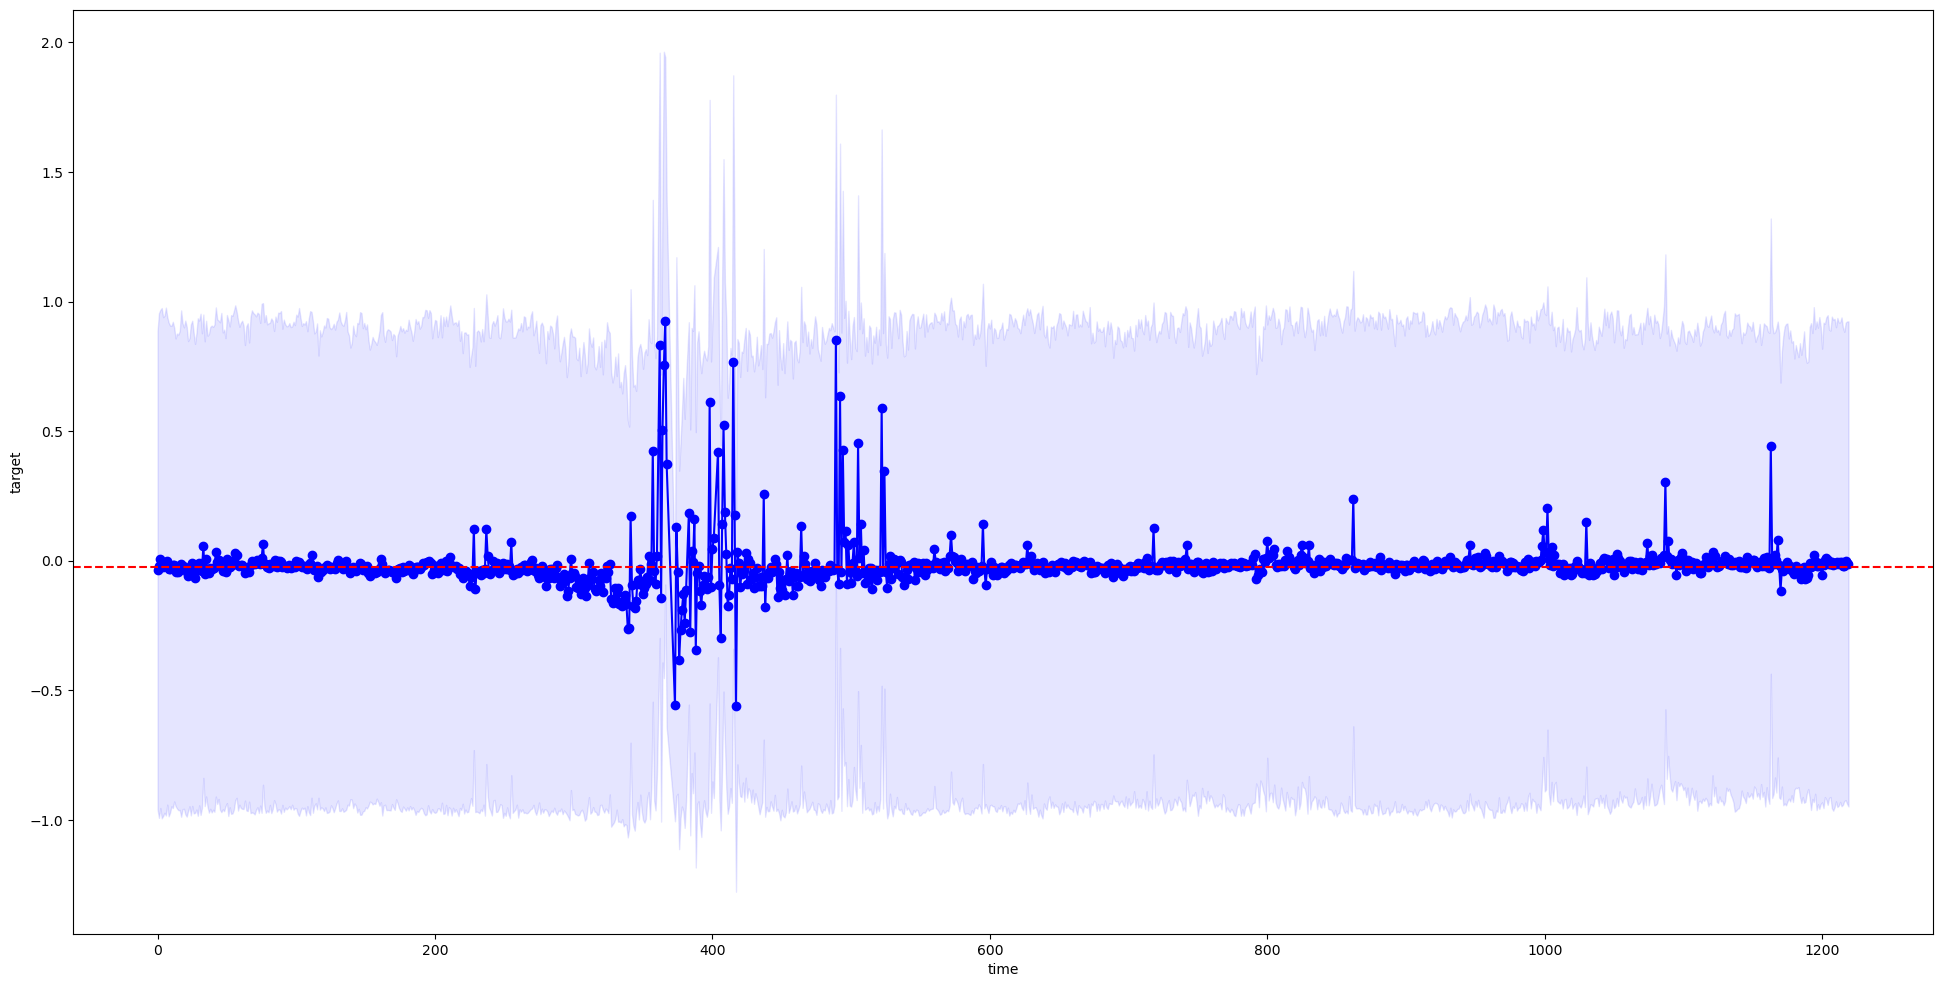

In [50]:
time2target_mean = df.groupby(['time_id'])['target'].mean()
time2target_std = df.groupby(['time_id'])['target'].std()

_, axes = plt.subplots(1, 1, figsize=(24, 12))
plt.fill_between(
        time2target_mean.index,
        time2target_mean - time2target_std,
        time2target_mean + time2target_std,
        alpha=0.1,
        color="b",
    )
plt.plot(
        time2target_mean.index, time2target_mean, "o-", color="b", label="Training score"
    )
plt.axhline(y=mean_mean_target, color='r', linestyle='--', label="mean")
axes.set_ylabel("target")
axes.set_xlabel("time")
plt.show()

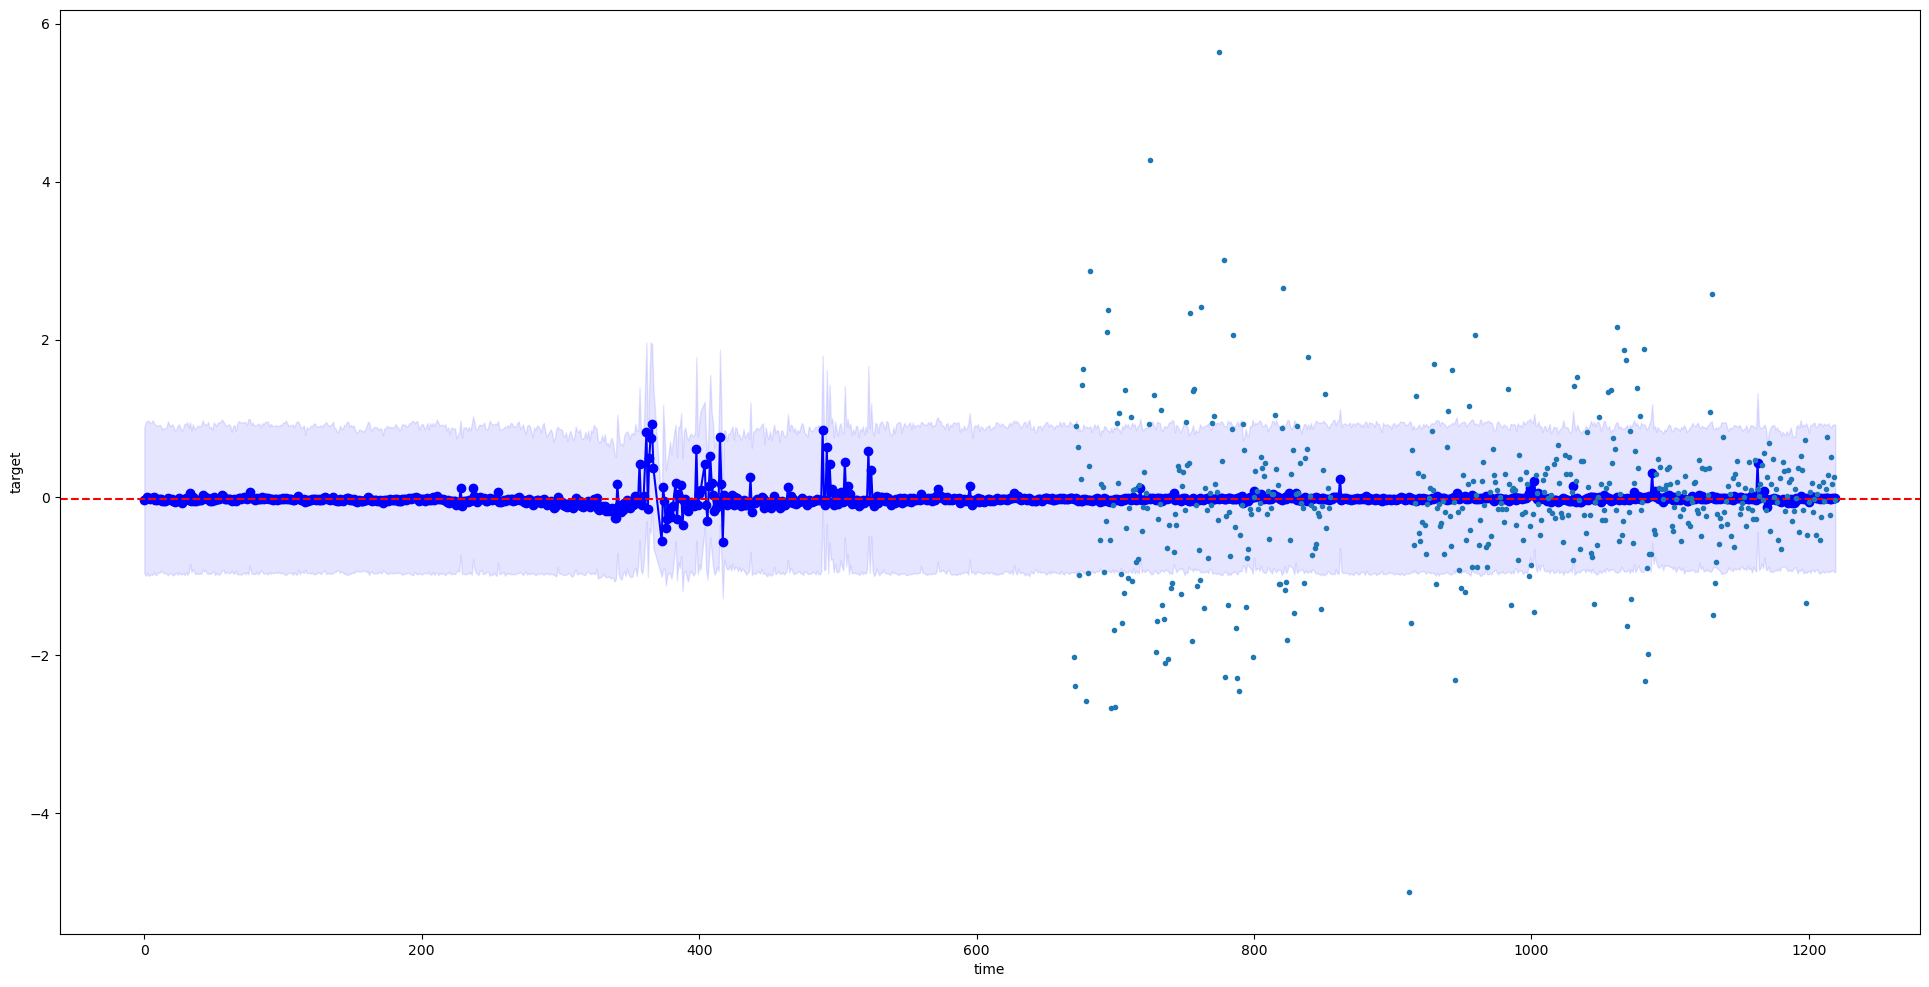

In [58]:
time2target_mean = df.groupby(['time_id'])['target'].mean()
time2target_std = df.groupby(['time_id'])['target'].std()

_, axes = plt.subplots(1, 1, figsize=(24, 12))
plt.fill_between(
        time2target_mean.index,
        time2target_mean - time2target_std,
        time2target_mean + time2target_std,
        alpha=0.1,
        color="b",
    )
plt.plot(
        time2target_mean.index, time2target_mean, "o-", color="b", label="Training score"
    )
plt.axhline(y=mean_mean_target, color='r', linestyle='--', label="mean")

asset = 70
plt.plot(df[df.investment_id==asset].time_id,
               df[df.investment_id==asset].target, '.')

axes.set_ylabel("target")
axes.set_xlabel("time")
plt.show()

In [69]:
obs_by_asset = df.groupby(['investment_id'])['target'].count().to_dict()
target = df.investment_id.copy().replace(obs_by_asset).astype(np.int16)
features = df.columns[4:]

del(obs_by_asset)

In [70]:
corrs = list()
for col in features:
    corr = np.corrcoef(target, df[col])[0][1]
    corrs.append(corr)
print(corrs)
del(target)

[0.00473649106157269, -0.018085109127428764, 0.06585488381484363, -0.16130316314012624, -0.17376571142993755, -0.0017500747845773292, -0.05815708369407797, 0.18735877664372738, 0.1304332051138446, -0.00820011348635325, 0.13326470750150762, 0.0030992294838032707, 0.05013301756913904, -0.004850396378247569, -0.0029554095387850973, -0.31521229377188614, -0.14646528567501846, -0.01589589665258119, 0.004464424718192859, 0.019186758257988216, 0.024744070428629618, 0.00023033087653434947, 0.48682286879649506, -0.14606692423431075, -0.009757767648623275, -0.22895207729240566, 0.007108705627034762, -0.004930452341427845, -0.19574821337012302, -0.0011652996634612476, 0.19715242295191035, -0.16035721742184755, 0.041973132848147215, 0.05782269695538853, 0.006375631998276405, -0.01907503425113094, -0.2690911179253727, 0.11297475331272189, 0.10420204647486375, -0.3128080309561372, 0.010579350853621858, -0.13700635277573942, -0.07037062869746408, 0.0029197004017155357, -0.01488333689352347, -0.281539

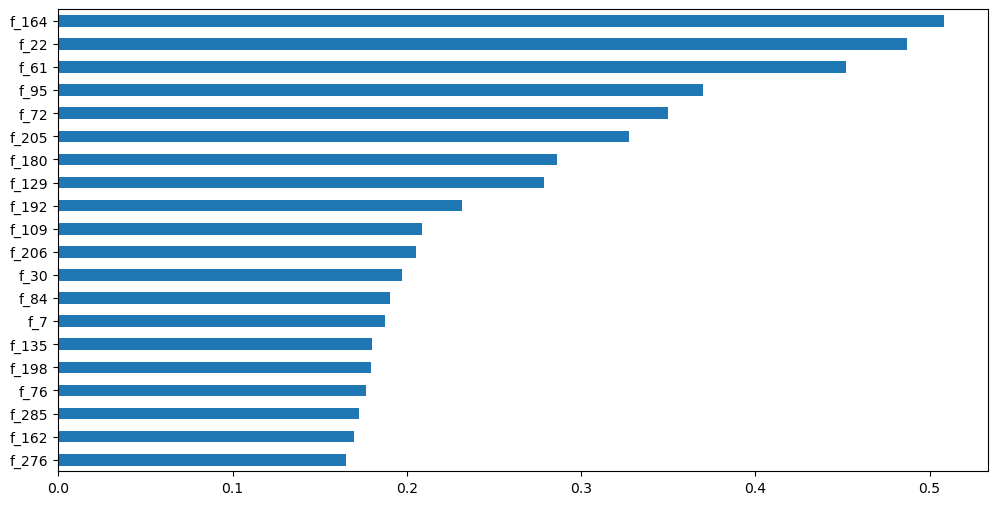

In [73]:
feat_importances = pd.Series(corrs, index=features)
feat_importances.nlargest(20).plot(kind='barh', figsize=(12, 6)).invert_yaxis()
plt.show()